# AI Image Recognition System Using MobileNetV2

## Objective
To recognize objects in an image using a pre-trained MobileNetV2 model.

In [2]:
%pip install tensorflow matplotlib numpy pillow

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 267s 2us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


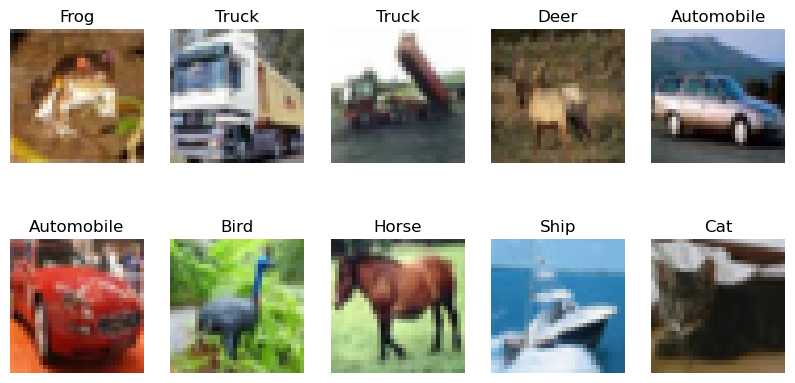

In [5]:
class_names=[
'Airplane','Automobile','Bird','Cat',
'Deer','Dog','Frog','Horse','Ship','Truck'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [7]:
x_train=x_train/255.0
x_test=x_test/255.0

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 502,688 (1.92 MB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 335,126 (1.28 MB)

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 31ms/step - accuracy: 0.4636 - loss: 1.4861 - val_accuracy: 0.5546 - val_loss: 1.2631
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.6063 - loss: 1.1235 - val_accuracy: 0.6240 - val_loss: 1.0777
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.6602 - loss: 0.9843 - val_accuracy: 0.6509 - val_loss: 1.0198
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.6859 - loss: 0.9032 - val_accuracy: 0.6794 - val_loss: 0.9306
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7122 - loss: 0.8315 - val_accuracy: 0.6971 - val_loss: 0.9031
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.7308 - loss: 0.7764 - val_accuracy: 0.6931 - val_loss: 0.9125
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.7464 - loss: 0.7299 - val_accuracy: 0.7081 - val_loss: 0.8752
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7608 -

In [13]:
 loss, accuracy = model.evaluate(x_test,y_test)

print("Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7137 - loss: 0.8730
Accuracy: 0.713699996471405


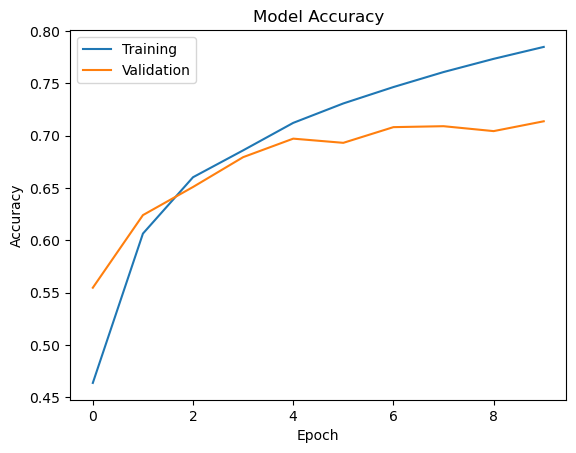

In [14]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Training","Validation"])

plt.show()

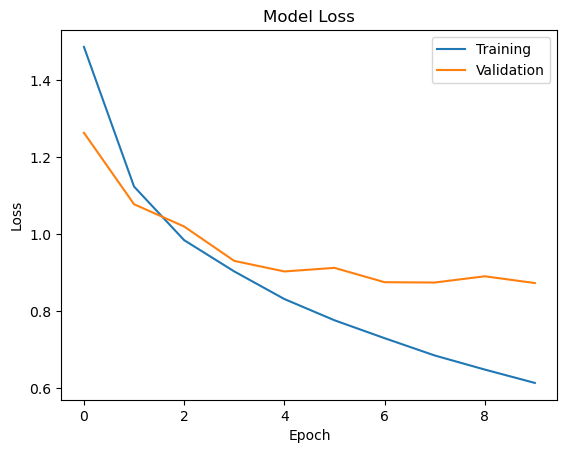

In [15]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Training","Validation"])

plt.show()

In [37]:
index = 99   # Change 5 to any index (0, 1, 2, 10, 50, ...)
prediction = model.predict(x_test[index:index+1])

predicted = class_names[np.argmax(prediction)]

print("Prediction:",predicted)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Prediction: Horse


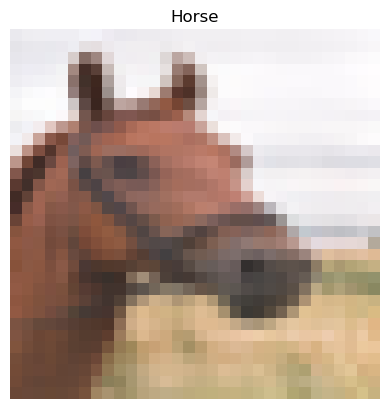

In [38]:
plt.imshow(x_test[index])

plt.title(predicted)

plt.axis("off")

plt.show()

In [20]:
model.save("saved_model.keras")

print("Model Saved Successfully")

Model Saved Successfully
